<a href="https://colab.research.google.com/github/mompaduck/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EC%A4%91%EA%B0%84%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
#한글깨짐 방지 -폰트설치 코드



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122815 files and d

In [1]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [15]:
#한국농수산식품유통공사 일별 도,소매 가격정보 조회의 데이터를 Open API를 활용하여 수집

import requests
import pandas as pd

API_KEY ='f475cd43dd3ea7f358af7c75801ceaa4d18c495f631d171dd2b8c16e607daccd'
BASE_URL = 'https://apis.data.go.kr/B552845/perDay/price'

# API 데이터 요청 함수
def request_data(year, variety_code, page_no=1, num_of_rows=200):

    params = {
        'serviceKey': API_KEY,
        'pageNo': page_no,
        'numOfRows': num_of_rows,
        'returnType': 'JSON',
        'cond[exmn_ymd::GTE]': f'{year}0101',
        'cond[exmn_ymd::LTE]': f'{year}1231',
        'cond[se_cd::EQ]': '02',
        'cond[ctgry_cd::EQ]': '200',
        'cond[item_cd::EQ]': '211',
        'cond[grd_cd::EQ]': '04',
        'cond[sgg_cd::EQ]': '1101',
        'cond[mrkt_cd::EQ]': '0110211',
        'cond[vrty_cd::EQ]': variety_code
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        # 성공 로그 (연도, 품종)
        print(f'[{year}년] [품종코드:{variety_code}] 🟢 API 호출 성공 (HTTP {response.status_code})')
        return response.json()

    except requests.exceptions.Timeout:
        print(f'[{year}년] [품종코드:{variety_code}] ⏱️ 요청 시간 초과')
        return None

    except requests.exceptions.RequestException as e:
        print(f'[{year}년] [품종코드:{variety_code}] ❌ API 요청 오류: {e}')
        return None

    except ValueError:
        print(f'[{year}년] [품종코드:{variety_code}] ❌ JSON 변환 오류')
        return None


# 배추 품종 코드
varieties = {'01':'봄배추','02':'여름배추(고랭지)','03':'가을배추','06':'월동배추'}

# 수집 기간 설정
start_year = 2015
end_year = 2024

# 전체 데이터 저장 리스트
all_data = []

# 2. 데이터 수집 루프
print('=== API 데이터 수집 시작 ===')
for year in range(start_year, end_year + 1):
    for variety_code, variety_name in varieties.items():
        page_no = 1

        while True:
            data = request_data(year, variety_code, page_no=page_no)

            if not data:
                continue
            try:
                body = data.get('response', {}).get('body', {})
                total_count = body.get('totalCount', 0)
                items = body.get('items', [])

                # API 응답 구조 예외 처리 (dict 형태로 들어올 경우 대응)
                if isinstance(items, dict):
                    items = items.get('item', [])

                if page_no == 1:
                    print(f'  └ [{variety_name}] totalCount: {total_count}건 (수집: {len(items)}건)')

                all_data.extend(items)

                # 모든 데이터를 수집했으면 루프 종료
                if len(items) < 200 or (page_no * 200) >= total_count:
                    break

                page_no += 1  # 다음 페이지로 이동

            except Exception as e:
                print(f'  └ [{variety_name}] ❌ 데이터 파싱 오류: {e}')

print('=== API 데이터 수집 완료 ===\n')


=== API 데이터 수집 시작 ===
[2015년] [품종코드:01] 🟢 API 호출 성공 (HTTP 200)
  └ [봄배추] totalCount: 66건 (수집: 66건)
[2015년] [품종코드:02] 🟢 API 호출 성공 (HTTP 200)
  └ [여름배추(고랭지)] totalCount: 64건 (수집: 64건)
[2015년] [품종코드:03] 🟢 API 호출 성공 (HTTP 200)
  └ [가을배추] totalCount: 45건 (수집: 45건)
[2015년] [품종코드:06] 🟢 API 호출 성공 (HTTP 200)
  └ [월동배추] totalCount: 97건 (수집: 97건)
[2016년] [품종코드:01] 🟢 API 호출 성공 (HTTP 200)
  └ [봄배추] totalCount: 70건 (수집: 70건)
[2016년] [품종코드:02] 🟢 API 호출 성공 (HTTP 200)
  └ [여름배추(고랭지)] totalCount: 72건 (수집: 72건)
[2016년] [품종코드:03] 🟢 API 호출 성공 (HTTP 200)
  └ [가을배추] totalCount: 48건 (수집: 48건)
[2016년] [품종코드:06] 🟢 API 호출 성공 (HTTP 200)
  └ [월동배추] totalCount: 87건 (수집: 87건)
[2017년] [품종코드:01] 🟢 API 호출 성공 (HTTP 200)
  └ [봄배추] totalCount: 67건 (수집: 67건)
[2017년] [품종코드:02] 🟢 API 호출 성공 (HTTP 200)
  └ [여름배추(고랭지)] totalCount: 57건 (수집: 57건)
[2017년] [품종코드:03] 🟢 API 호출 성공 (HTTP 200)
  └ [가을배추] totalCount: 48건 (수집: 48건)
[2017년] [품종코드:06] 🟢 API 호출 성공 (HTTP 200)
  └ [월동배추] totalCount: 86건 (수집: 86건)
[2018년] [품종코드:01] 🟢 API 호출 성공 

In [ ]:
import requests

# 기본 설정 (API URL 및 API Key)
url = 'YOUR_API_URL_HERE'        # 실제 API Endpoint URL
api_key = 'YOUR_API_KEY_HERE'    # 실제 발급받은 API 키

# 1. API 데이터 요청 함수
def request_data(year, variety_code, page_no=1, num_of_rows=200):
    params = {
        'serviceKey': api_key,
        'pageNo': page_no,
        'numOfRows': num_of_rows,
        'returnType': 'JSON',
        'cond[exmn_ymd::GTE]': f'{year}0101',
        'cond[exmn_ymd::LTE]': f'{year}1231',
        'cond[se_cd::EQ]': '02',
        'cond[ctgry_cd::EQ]': '200',
        'cond[item_cd::EQ]': '211',
        'cond[grd_cd::EQ]': '04',
        'cond[sgg_cd::EQ]': '1101',
        'cond[mrkt_cd::EQ]': '0110211',
        'cond[vrty_cd::EQ]': variety_code
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        return response.json()

    except requests.exceptions.Timeout:
        print(f'[{year}년] [코드:{variety_code}] ⏱️ 요청 시간 초과')
    except requests.exceptions.RequestException as e:
        print(f'[{year}년] [코드:{variety_code}] ❌ API 요청 오류: {e}')
    except ValueError:
        print(f'[{year}년] [코드:{variety_code}] ❌ JSON 변환 오류')

    return None


# 배추 품종 코드 및 수집 기간 설정
varieties = {
    '01': '봄배추',
    '02': '여름배추(고랭지)',
    '03': '가을배추',
    '06': '월동배추'
}

start_year = 2015
end_year = 2024

all_data = []

# 2. 데이터 수집 루프 (단일 호출 방식)
print('=== API 데이터 수집 시작 ===')

for year in range(start_year, end_year + 1):
    for variety_code, variety_name in varieties.items():

        # 연도/품종별 1회 호출 (기본 200건)
        data = request_data(year, variety_code)

        if not data:
            continue

        try:
            body = data.get('response', {}).get('body', {})
            total_count = body.get('totalCount', 0)
            items = body.get('items', [])

            # items가 dict 형태로 들어오는 경우 처리
            if isinstance(items, dict):
                items = items.get('item', [])

            print(f'[{year}년] [{variety_name}] totalCount: {total_count}건 (수집: {len(items)}건)')
            all_data.extend(items)

        except Exception as e:
            print(f'  └ [{variety_name}] ❌ 데이터 파싱 오류: {e}')

print(f'\n=== API 데이터 수집 완료 (총 {len(all_data):,}건 수집됨) ===')

In [3]:


# 수집된 리스트 데이터를 DataFrame으로 변환하고 데이터의 기본 정보를 출력
# DataFrame 변환
df = pd.DataFrame(all_data)

print("=== 데이터 기본 정보 ===")
print("데이터 크기(행, 열):", df.shape)
print("\n컬럼 목록:", df.columns.tolist())

# 1. 요약 정보 (타입 + Non-Null 개수 + 메모리)
print("\n=== 데이터 요약 정보 (info) ===")
df.info()

# 2. 결측치 수 확인
print("\n=== 컬럼별 결측치 개수 ===")
print(df.isnull().sum())

# 3. 중복 데이터 확인
print("\n=== 중복 데이터 개수 ===")
print(f"중복 행 수: {df.duplicated().sum()}건")

# 4. 데이터 샘플 및 통계
print("\n=== 데이터 상단 5건 ===")
print(df.head())

print("\n=== 기술 통계량 ===")
print(df.describe(include="all"))



=== 데이터 기본 정보 ===
데이터 크기(행, 열): (2644, 20)

컬럼 목록: ['ctgry_cd', 'ctgry_nm', 'exmn_dd_cnvs_prc', 'exmn_dd_prc', 'exmn_ymd', 'grd_cd', 'grd_nm', 'item_cd', 'item_nm', 'mrkt_cd', 'mrkt_nm', 'orgnl_reg_dt', 'se_cd', 'se_nm', 'sgg_cd', 'sgg_nm', 'unit', 'unit_sz', 'vrty_cd', 'vrty_nm']

=== 데이터 요약 정보 (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ctgry_cd          2644 non-null   object
 1   ctgry_nm          2644 non-null   object
 2   exmn_dd_cnvs_prc  2644 non-null   object
 3   exmn_dd_prc       2644 non-null   object
 4   exmn_ymd          2644 non-null   object
 5   grd_cd            2644 non-null   object
 6   grd_nm            2644 non-null   object
 7   item_cd           2644 non-null   object
 8   item_nm           2644 non-null   object
 9   mrkt_cd           2644 non-null   object
 10  mrkt_nm           2644 non-n

In [30]:
import pandas as pd

# 월별 계절 매핑 딕셔너리
SEASON_MAP = {
    3: '봄', 4: '봄', 5: '봄',
    6: '여름', 7: '여름', 8: '여름',
    9: '가을', 10: '가을', 11: '가을',
    12: '겨울', 1: '겨울', 2: '겨울',
}

# 날짜형 변환 및 연도/계절 컬럼 추가
if 'exmn_ymd' in df.columns:
    df['exmn_ymd'] = pd.to_datetime(df['exmn_ymd'], format='%Y%m%d')
    df['year'] = df['exmn_ymd'].dt.year
    df['season'] = df['exmn_ymd'].dt.month.map(SEASON_MAP)

print('\n=== 계절별 전처리 결과 샘플 (4개 계절 확인) ===')
season_sample = df.groupby('season', as_index=False).first()
season_order = ['봄', '여름', '가을', '겨울']
season_sample['season'] = pd.Categorical(season_sample['season'],
                                            categories=season_order, ordered=True)
season_sample = season_sample.sort_values('season')
print(season_sample[['exmn_ymd', 'year', 'season']])

print('\n=== 연도 및 계절 전처리 결과 (랜덤 20건) ===')
print(df[['exmn_ymd', 'year', 'season']].sample(20, random_state=42))



=== 계절별 전처리 결과 샘플 (4개 계절 확인) ===
    exmn_ymd  year season
2 2015-05-12  2015      봄
3 2015-06-01  2015     여름
0 2015-09-01  2015     가을
1 2015-01-02  2015     겨울

=== 연도 및 계절 전처리 결과 (랜덤 20건) ===
       exmn_ymd  year season
889  2018-09-03  2018     가을
1110 2019-07-16  2019     여름
1309 2019-04-25  2019      봄
727  2017-01-10  2017     겨울
1027 2018-03-16  2018      봄
1472 2020-11-06  2020     가을
748  2017-02-10  2017     겨울
1264 2019-02-20  2019     겨울
2617 2024-04-22  2024      봄
1612 2021-05-04  2021      봄
2259 2023-11-20  2023     가을
32   2015-06-26  2015     여름
794  2017-04-18  2017      봄
1659 2021-07-12  2021     여름
1772 2021-01-18  2021     겨울
1213 2019-12-03  2019     겨울
840  2018-06-27  2018     여름
2514 2024-11-07  2024     가을
173  2015-12-30  2015     겨울
857  2018-07-18  2018     여름


In [14]:
# 날짜형 변환 및 연도/계절 컬럼 추가
if 'exmn_ymd' in df.columns:
    df['exmn_ymd'] = pd.to_datetime(df['exmn_ymd'], format='%Y%m%d')
    df['year'] = df['exmn_ymd'].dt.year
    df['season'] = df['exmn_ymd'].dt.month.map(SEASON_MAP)

    print('\n=== 연도 및 계절 전처리 결과 (상단 20건) ===')
    print(df[['exmn_ymd', 'year', 'season']].head(20))


=== 연도 및 계절 전처리 결과 (상단 20건) ===
     exmn_ymd  year season
0  2015-05-12  2015      봄
1  2015-05-13  2015      봄
2  2015-05-14  2015      봄
3  2015-05-15  2015      봄
4  2015-05-18  2015      봄
5  2015-05-19  2015      봄
6  2015-05-20  2015      봄
7  2015-05-21  2015      봄
8  2015-05-22  2015      봄
9  2015-05-26  2015      봄
10 2015-05-27  2015      봄
11 2015-05-28  2015      봄
12 2015-05-29  2015      봄
13 2015-06-01  2015     여름
14 2015-06-02  2015     여름
15 2015-06-03  2015     여름
16 2015-06-04  2015     여름
17 2015-06-05  2015     여름
18 2015-06-08  2015     여름
19 2015-06-09  2015     여름


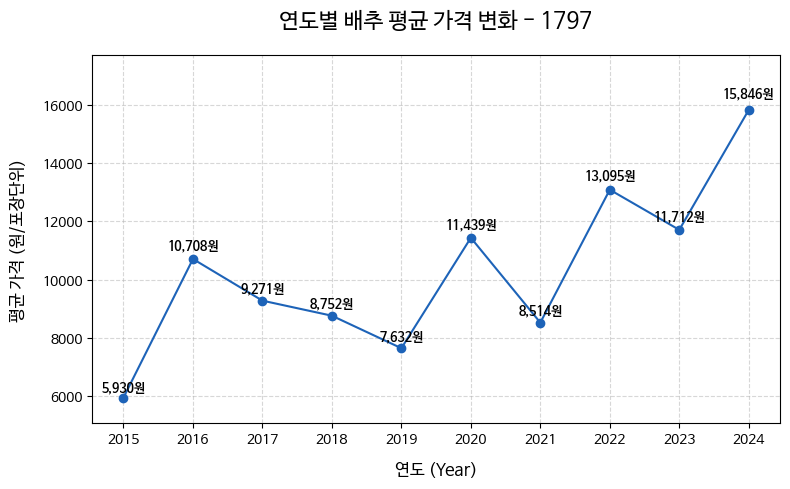

<Figure size 640x480 with 0 Axes>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 연도별 배추 평균 가격 변화량을 선 그래프로 시각화

# 가격 컬럼 숫자형 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

# 연도별 평균 가격 집계
yearly_avg = df.groupby('year')['exmn_dd_prc'].mean().reset_index()

# 그래프 생성
plt.figure(figsize=(8, 5))
plt.plot(
    yearly_avg['year'],
    yearly_avg['exmn_dd_prc'],
    marker='o',
    color='#1D63B8',
    linewidth=1.5,
    markersize=6
)

# 각 데이터 점(마커) 위에 구체적인 평균 가격 수치 표시
for year, price in zip(yearly_avg['year'], yearly_avg['exmn_dd_prc']):
    plt.text(
        year,
        price * 1.02,
        f'{price:,.0f}원',
        ha='center',
        va='bottom', fontsize=9, fontweight='bold'
    )

# Y축 범위 자동 설정
max_val = yearly_avg['exmn_dd_prc'].max()
min_val = yearly_avg['exmn_dd_prc'].min()
plt.ylim(min_val * 0.85, max_val * 1.12)

# 제목 및 축 라벨 설정
plt.title('연도별 배추 평균 가격 변화 - 1797', fontsize=16, pad=20)
plt.xlabel('연도 (Year)', fontsize=12, labelpad=10)
plt.ylabel('평균 가격 (원/포장단위)', fontsize=12, labelpad=10)

# X축 연도 눈금 설정
plt.xticks(yearly_avg['year'].astype(int))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# 6. 이미지 저장 및 출력
filename = f'cabbage_price_line.png'
plt.savefig(filename, dpi=300)
# print(f'🟢 그래프 저장 완료: {filename}')



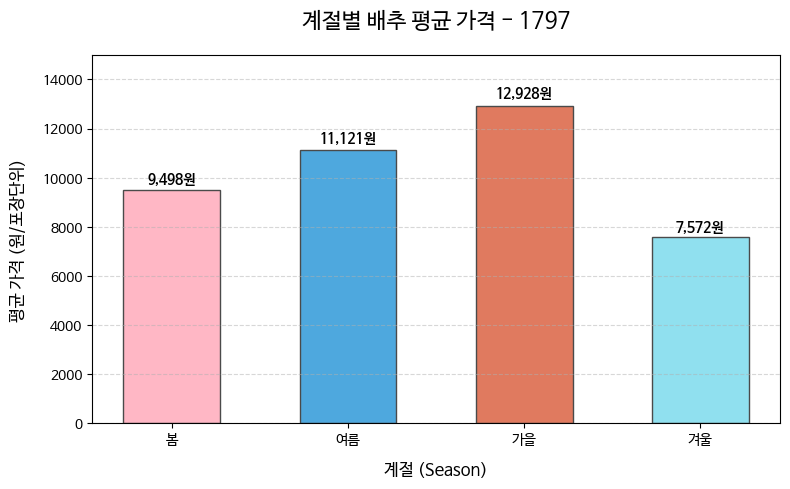

🟢 그래프 저장 완료: cabbage_price_bar.png


<Figure size 640x480 with 0 Axes>

In [32]:
 # 계절별 배추 평균 가격을 막대 그래프

 # 가격 컬럼 숫자형 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

# 2. 계절 정렬 순서 및 평균 가격 집계 (봄 -> 여름 -> 가을 -> 겨울)
season_order = ['봄', '여름', '가을', '겨울']
seasonal_avg = df.groupby('season')['exmn_dd_prc'].mean().reindex(season_order).reset_index()

# 4. 막대 그래프 생성
plt.figure(figsize=(8, 5))
colors = ['#FFB7C5', '#4EA8DE', '#E07A5F', '#90E0EF'] # 계절별 구분 색상

bars = plt.bar(
    seasonal_avg['season'],
    seasonal_avg['exmn_dd_prc'],
    color=colors,
    edgecolor='#4A4A4A',
    width=0.55
)

# 5. 각 막대 상단에 구체적인 수치(가격) 표시
for bar, price in zip(bars, seasonal_avg['exmn_dd_prc']):
    if pd.notna(price) and price > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # 막대 중앙 X 위치
            price * 1.015,                      # Y 위치 (1.5% 위)
            f'{price:,.0f}원',                   # 천 단위 콤마 포맷팅
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
# for bar in bars:
#     height = bar.get_height()

#     plt.text(
#         bar.get_x() + bar.get_width() / 2.0,  # X축 위치 (막대 중앙)
#         height + (height * 0.015),             # Y축 위치 (막대 살짝 위)
#         f'{height:,.0f}원',                    # 1,000단위 콤마 포맷팅
#         ha='center',
#         va='bottom',
#         fontsize=10,
#         fontweight='bold'
#     )

# 6. 제목 및 축 라벨 설정
plt.title('계절별 배추 평균 가격 - 1797', fontsize=16, pad=20)
plt.xlabel('계절 (Season)', fontsize=12, labelpad=10)
plt.ylabel('평균 가격 (원/포장단위)', fontsize=12, labelpad=10)

# Y축 범위 자동 확보 및 그리드 설정
max_val = seasonal_avg['exmn_dd_prc'].max()

# Y축 범위 및 가로 그리드 설정
plt.ylim(0, 15000)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# 이미지 저장 및 출력
filename = f'cabbage_price_bar.png'
plt.savefig(filename, dpi=300)
print(f'🟢 그래프 저장 완료: {filename}')

